In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [2]:
X_train = [[6], [8], [10], [14], [18]]
y_train = [[7], [9], [13], [17.5], [18]]
X_test = [[6], [8], [11], [16]]
y_test = [[8], [12], [15], [18]]

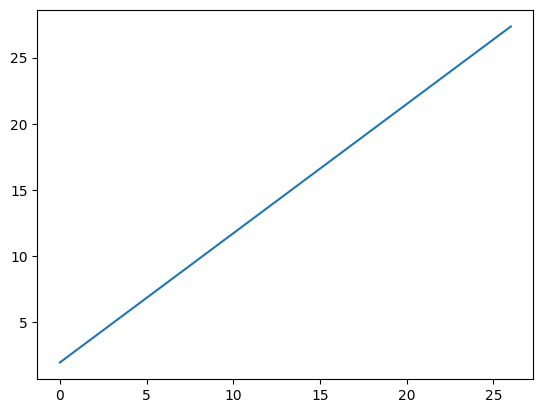

In [3]:
# 2. Simple Linear Regression (Blue Line)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
xx = np.linspace(0, 26, 100).reshape(-1, 1) # Create 100 points from 0-26
yy = regressor.predict(xx)
plt.plot(xx, yy, label='Linear Regression')

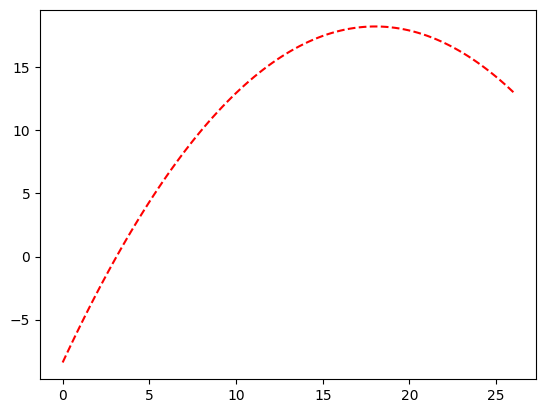

In [4]:
#3. Quadratic Regression (Red Dashed Line)
# Degree=2 means we create a feature for x^2
quadratic_featurizer = PolynomialFeatures(degree=2)
X_train_quadratic = quadratic_featurizer.fit_transform(X_train)
X_test_quadratic = quadratic_featurizer.transform(X_test)

regressor_quadratic = LinearRegression()
regressor_quadratic.fit(X_train_quadratic, y_train)

xx_quadratic = quadratic_featurizer.transform(xx)
plt.plot(xx, regressor_quadratic.predict(xx_quadratic), c='r', linestyle='--', label='Quadratic Regression')

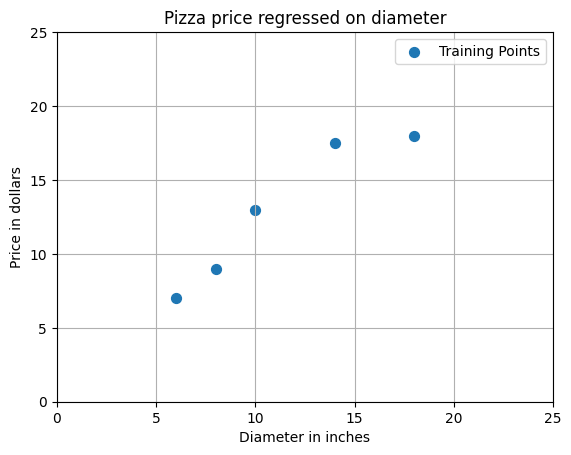

In [5]:
# 4. Visualization
plt.title('Pizza price regressed on diameter')
plt.xlabel('Diameter in inches')
plt.ylabel('Price in dollars')
plt.axis([0, 25, 0, 25])
plt.grid(True)
plt.scatter(X_train, y_train, s=50, label='Training Points')
plt.legend()
plt.show()

In [6]:
#5. Print Results
print("X_train (Original):\n", X_train)
print("\nX_train_quadratic (Includes x^0, x^1, x^2):\n", X_train_quadratic)

print(f'\nSimple linear regression r-squared: {regressor.score(X_test, y_test):.4f}')
print(f'Quadratic regression r-squared: {regressor_quadratic.score(X_test_quadratic, y_test):.4f}')

X_train (Original):
 [[6], [8], [10], [14], [18]]

X_train_quadratic (Includes x^0, x^1, x^2):
 [[  1.   6.  36.]
 [  1.   8.  64.]
 [  1.  10. 100.]
 [  1.  14. 196.]
 [  1.  18. 324.]]

Simple linear regression r-squared: 0.8097
Quadratic regression r-squared: 0.8675
